## Feature scaling
- When inputs have different scales (range) then: 
    - Loss surface becomes elongated
    - Gradients oscillate
    - Training becomes slow and unstable
    

Take the example below with two feature weights:   
- Left side have equal feature scales 
- Right side have uneqal feature scales and hence weights space is elongated

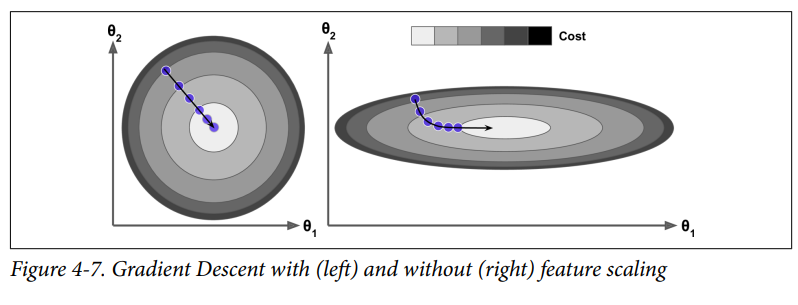

1. Standard Scaler
$$ x = \frac{x-\bar{x}}{\sigma}$$
- Output features are centered to mean: Mean = 0, std = 1

2. Normalizer
$$ x = \frac{x-x_{min}}{x_{max} - x_{min}}$$
- Output features have range: 0-1

### When to normalize OR standardize?
- If we know upper and lower limit of data then - _Normalize_,   
    - example: cgpa

- If feature does not have fixed upper or lower limit then - _Standardize_
    - example: salary

- If data is normally distributed - _Standardize_

#### Without Feature Scaling

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras import Sequential
from keras.layers import Input, Dense
from keras.callbacks import EarlyStopping

In [43]:
data = pd.read_csv(r"C:\Users\Arun\Documents\Documents\Deep Learning\1_Introduction_To_ANNs\datasets\Socail_Network\Social_Network_Ads.csv")
data.drop(columns=['User ID', 'Gender'],inplace=True)
data.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [44]:
x_train, x_test, y_train, y_test = train_test_split(data.iloc[:,0:2],data.iloc[:,-1],test_size=0.2)

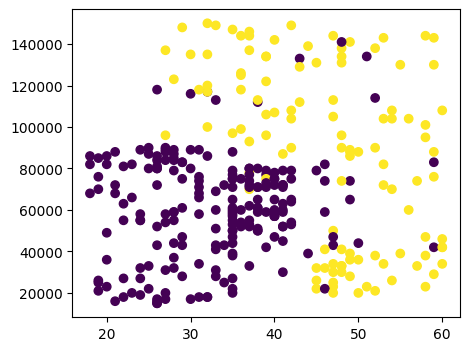

In [45]:
plt.figure(figsize=(5,4))
plt.scatter(x_train.iloc[:,0],x_train.iloc[:,1],c=y_train)

In [46]:
model = Sequential()

model.add(Input(shape=(x_train.shape[1],)))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation ='relu'))
model.add(Dense(1,activation='sigmoid'))

model.compile(optimizer='Adam', loss='binary_crossentropy',metrics=['Accuracy'])

callback = EarlyStopping(
    monitor='val_loss',
    min_delta=0.0001,
    patience=50,
    mode='auto',
    verbose=1,
    restore_best_weights=True
)
history = model.fit(x_train,y_train, epochs=100,batch_size=x_train.shape[0], validation_data=(x_test,y_test),callbacks=callback)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 834ms/step - Accuracy: 0.3531 - loss: 1475.0797WARNING:tensorflow:6 out of the last 204 calls to <function TensorFlowTrainer._make_function.<locals>.multi_step_on_iterator at 0x00000230B09D7D80> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - Accuracy: 0.3531 - loss: 1475.0797 - val_Accuracy: 0.3750 - val_loss: 122.7576
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - Accuracy: 0.3531 - loss: 133

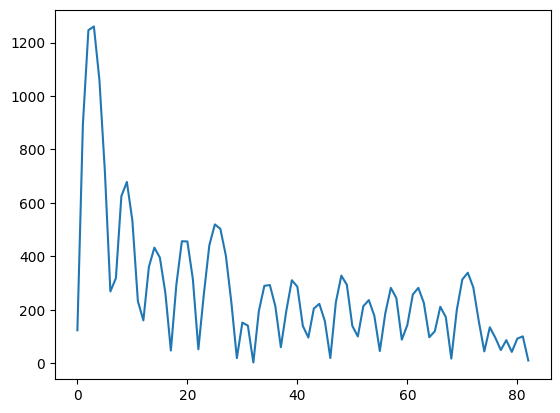

In [47]:
plt.plot(history.history['val_loss'])

#### With Feature Scaling

In [48]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

This plot will be exactly same, except only scale of features is different

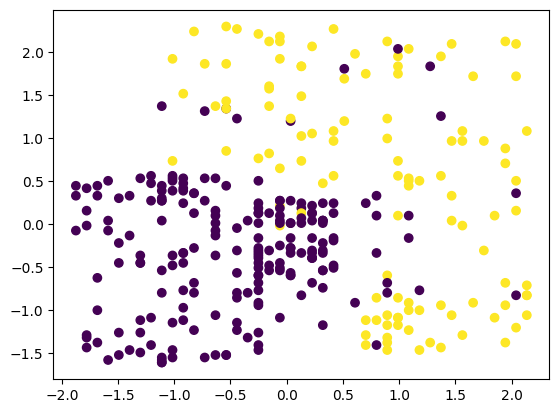

In [49]:
plt.scatter(x_train_scaled[:,0],x_train_scaled[:,1],c=y_train)

In [50]:
model = Sequential()

model.add(Input(shape=(x_train_scaled.shape[1],)))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation ='relu'))
model.add(Dense(1,activation='sigmoid'))

model.compile(optimizer='Adam', loss='binary_crossentropy',metrics=['Accuracy'])

callback = EarlyStopping(
    monitor='val_loss',
    min_delta=0.0001,
    patience=50,
    mode='auto',
    verbose=1,
    restore_best_weights=True
)
history = model.fit(x_train_scaled,y_train, epochs=100,batch_size=x_train_scaled.shape[0], validation_data=(x_test_scaled,y_test),callbacks=callback)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - Accuracy: 0.5562 - loss: 0.7110 - val_Accuracy: 0.6250 - val_loss: 0.6952
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - Accuracy: 0.6469 - loss: 0.6943 - val_Accuracy: 0.6250 - val_loss: 0.6789
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - Accuracy: 0.6781 - loss: 0.6783 - val_Accuracy: 0.7000 - val_loss: 0.6632
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - Accuracy: 0.7375 - loss: 0.6630 - val_Accuracy: 0.7500 - val_loss: 0.6482
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - Accuracy: 0.7688 - loss: 0.6483 - val_Accuracy: 0.7375 - val_loss: 0.6339
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - Accuracy: 0.7875 - loss: 0.6343 - val_Accuracy: 0.7625 - val_loss: 0.6201
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - Accuracy: 0.7937 - loss: 0.6208 - val_Accuracy: 0.7750 - val_loss: 0.6068
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - Accuracy: 0.8062 - loss: 0.6078 - val_Accuracy: 0.7750 - val_loss

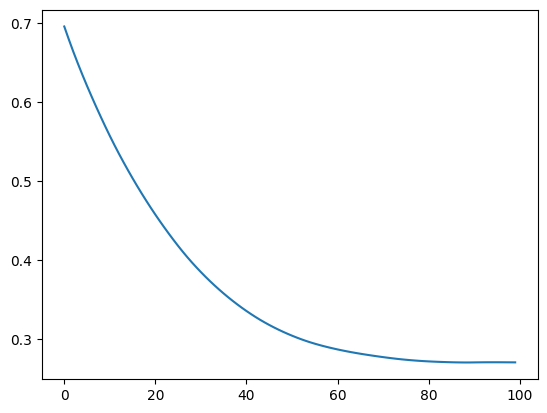

In [52]:
plt.plot(history.history['val_loss'])